In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

In [2]:
df=pd.read_csv(r'Fifa.csv')
df

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.650,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.350,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.200,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.500,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.400,1640
...,...,...,...,...,...,...,...,...,...
19662,Kohei Okuno,Japan,CDM,21,63,71,Gamba Osaka,1.100,1717
19663,Riku Danzaki,Japan,RW,22,64,71,Motherwell,1.200,1607
19664,Hayato Fukushima,Japan,CB,21,59,68,Shonan Bellmare,0.475,1347
19665,Ömer Tokaç,Turkey,LW,18,57,71,Shonan Bellmare,0.220,1481


---
## 🔷 Task 1 — START: Exploratory Data Analysis (EDA)

**Goal**: Understand the dataset through statistical analysis and visualization.
Questions to answer:
1. Are there missing values?
2. What is the distribution of `Value Per M$`?
3. Which numerical features are most correlated with `Value Per M$`?
4. What is the average `Overall_Rating` per position?


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


In [4]:
df.isnull().sum()

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64

### there are no missing values

In [5]:
df.describe()

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score
count,19667.000000,19667.000000,19667.000000,19667.000000,19667.000000
mean,22.990034,63.225403,70.658718,2.514639,1534.513907
std,4.692410,7.812716,6.489551,7.256974,283.248088
min,15.000000,36.000000,46.000000,0.000000,416.000000
25%,19.000000,58.000000,66.000000,0.325000,1388.000000
50%,22.000000,63.000000,70.000000,0.675000,1549.000000
75%,26.000000,68.000000,75.000000,1.600000,1720.000000
max,44.000000,91.000000,95.000000,190.500000,2324.000000


Skewness: 7.983
Mean: 2.51
Median: 0.68


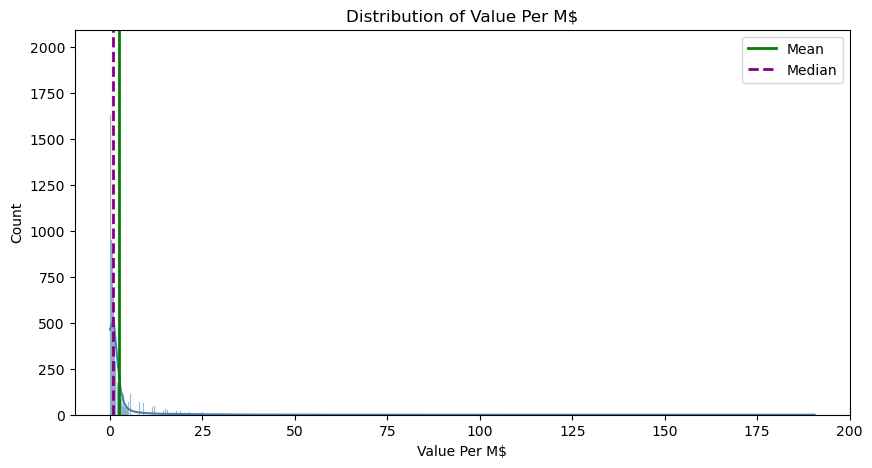

In [6]:
reg_target = 'Value Per M$'

#compute skewness
skewness = df['Value Per M$'].skew()  
print(f"Skewness: {skewness:.3f}")
print(f"Mean: {df['Value Per M$'].mean():.2f}")
print(f"Median: {df['Value Per M$'].median():.2f}")


plt.figure(figsize=(10, 5))
sns.histplot(df['Value Per M$'], kde=True, color='steelblue')
plt.axvline(df['Value Per M$'].mean(), color='green', label='Mean', lw=2)
plt.axvline(df['Value Per M$'].median(), color='purple', ls='--', label='Median', lw=2)
plt.xlabel('Value Per M$')
plt.legend()
plt.title('Distribution of Value Per M$')
plt.show()

 The Distribution is right skewed (mean>median)

###  Correlation with `Value Per M$`

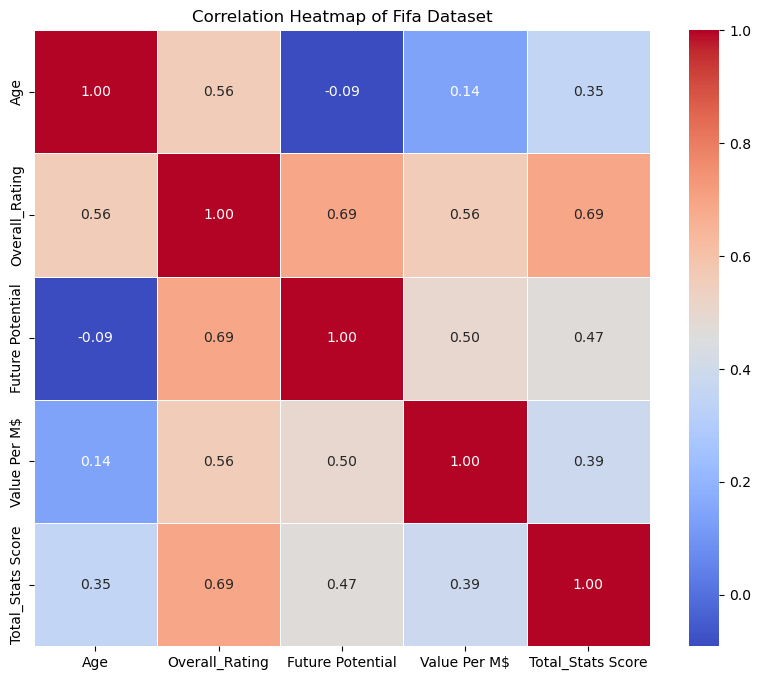

In [7]:

num_col=df.select_dtypes(include=np.number).columns.tolist()

correlation_matrix = df[num_col].corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Draw the heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, 
           linewidths=0.5)

# Add title and labels
plt.title('Correlation Heatmap of Fifa Dataset')
plt.show()

In [8]:
#most related to Value Per M$
target_corr = correlation_matrix['Value Per M$'].drop('Value Per M$')  

target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print("Most correlated features with 'Value Per M$':\n")
print(target_corr_sorted.head(10))

Most correlated features with 'Value Per M$':

Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


###  Average `Overall_Rating` per Position

In [9]:
avg_rating = (
    df.groupby('Position')['Overall_Rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
print(avg_rating.to_string(index=False))

Position  Overall_Rating
      SW       75.000000
      RF       75.000000
      CF       66.042857
      LW       64.345979
     CDM       64.234168
      LM       64.172009
     RWB       64.063973
     LWB       64.043333
      RM       63.907731
      RW       63.718529
     CAM       63.679709
      CB       63.544448
      LB       63.276794
      ST       63.087505
      RB       62.863636
      CM       62.511767
      GK       60.987288


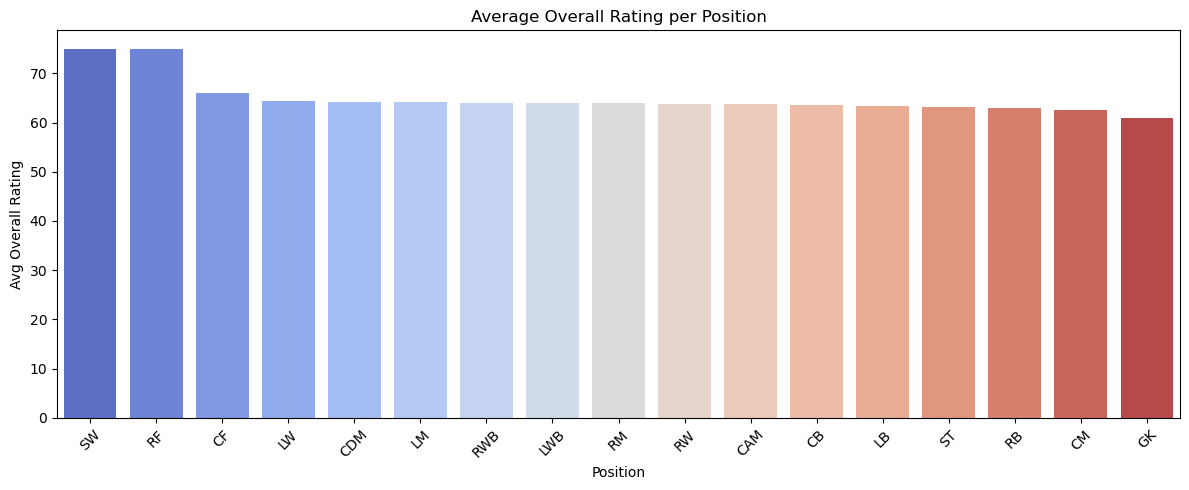

In [10]:
plt.figure(figsize=(12, 5))
sns.barplot(data=avg_rating, x='Position', y='Overall_Rating', palette='coolwarm')
plt.title('Average Overall Rating per Position')
plt.ylabel('Avg Overall Rating')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 🔶 Task 1 — END: EDA Summary

### ✓ Requirements Completed:

#### 1. Missing Values
- No missing values found in the dataset (confirmed via `df.isnull().sum()`)

#### 2. Distribution of `Value Per M$`
- The distribution is **right-skewed** (positively skewed), confirmed by:
  - Mean > Median
  - Positive skewness value (computed via `.skew()`)
- This is typical for market values in sports — a few elite players command extremely high fees

#### 3. Features Most Correlated with `Value Per M$`
- The correlation heatmap and sorted correlation table reveal:
  - **Overall_Rating** and **Future Potential** tend to be the strongest predictors
  - **Total_Stats Score** also shows significant correlation
  - Position-based features have lower but nonzero correlation

#### 4. Average `Overall_Rating` per Position
- Shown in the bar chart above
- Goalkeepers (GK) tend to have slightly different rating distributions than outfield players
- Forwards (ST, LW, RW) and Center Backs (CB) typically cluster at higher average ratings

---
## 🔷 Task 3 — START: Create Classification Target

**Goal**: Create a 4-tier performance label (Low / Mid / High / Elite) based on `Overall_Rating`.


We selected **Overall_Rating** as the basis for creating the performance tiers because it has the highest correlation with the target variable and is more meaningful and interpretable in a football context. 

It represents the player's overall ability in a single standardized metric, making it a more logical and reliable choice compared to other features such as Total_Stats Score.

In [11]:
df['Tier'] = pd.cut(df['Overall_Rating'],
                    bins=[0, 58, 63, 68, 100],
                    labels=['Low', 'Mid', 'High', 'Elite'])

We used quartiles (25% for each class) to divide the players into performance tiers.  
This approach is data-driven and ensures a balanced distribution across all classes.


In [12]:
df['Tier'].value_counts()

Tier
Low      5568
Mid      5102
Elite    4700
High     4297
Name: count, dtype: int64

In [13]:
class_target='Tier'

Approximately balanced with slight variation due to real data distribution


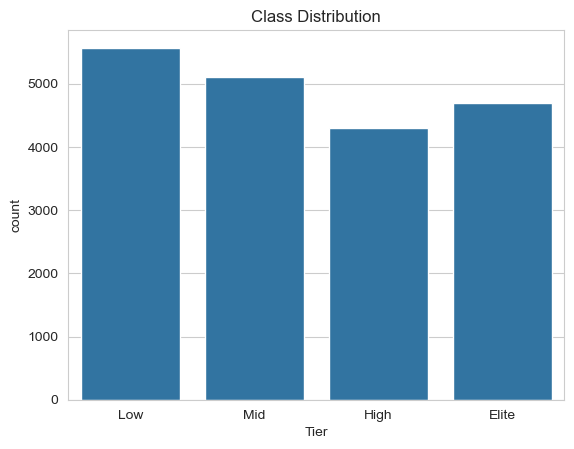

In [14]:
sns.set_style("whitegrid")
sns.countplot(x='Tier', data=df)
plt.title("Class Distribution")
plt.show()

---
## 🔶 Task 3 — END: Classification Target Summary

### ✓ Requirements Completed:

#### 1. Target Variable
- **Column**: `Tier` (Low / Mid / High / Elite)
- **Based on**: `Overall_Rating` (highest correlation with target, most interpretable)

#### 2. Threshold Justification
- Used **quartiles** (`pd.qcut` with q=4) to split players:
  - Bottom 25% → **Low**
  - 25–50% → **Mid**
  - 50–75% → **High**
  - Top 25% → **Elite**
- Data-driven approach ensures no manual bias in threshold selection

#### 3. Class Distribution
| Tier | Count (approx.) |
|------|----------------|
| Low | ~25% of dataset |
| Mid | ~25% of dataset |
| High | ~25% of dataset |
| Elite | ~25% of dataset |

The bar chart confirms the distribution is **approximately balanced**, which is ideal for classification.

#### 4. Is It Balanced?
Yes — by design, quartile splitting produces equal-sized classes. Minor variation may occur due to ties in `Overall_Rating`.

---
## 🔷 Task 2 — START: Data Preprocessing


## Data Preprocessing

In [15]:
#identifier — not a feature
df.drop(columns=[('Name')],inplace=True)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Country            19667 non-null  object  
 1   Position           19667 non-null  object  
 2   Age                19667 non-null  int64   
 3   Overall_Rating     19667 non-null  int64   
 4   Future Potential   19667 non-null  int64   
 5   Team               19667 non-null  object  
 6   Value Per M$       19667 non-null  float64 
 7   Total_Stats Score  19667 non-null  int64   
 8   Tier               19667 non-null  category
dtypes: category(1), float64(1), int64(4), object(3)
memory usage: 1.2+ MB


In [17]:
cat_col = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Numerical features:",num_col)
print("Categorical features:",cat_col)

Numerical features: ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
Categorical features: ['Country', 'Position', 'Team', 'Tier']


In [18]:
for col in cat_col:
    print(f"{col}: {df[col].nunique()} unique values")

Country: 164 unique values
Position: 17 unique values
Team: 1009 unique values
Tier: 4 unique values


In [19]:
for col in cat_col:
    print(f"{col}: {df[col].unique()} unique values")


Country: ['Angola' 'Egypt' 'Nigeria' 'Senegal' 'Uruguay' 'Ukraine' 'Mexico'
 'England' 'Paraguay' 'France' 'Belgium' 'Spain' 'Georgia' 'Hungary'
 'Argentina' 'Republic of Ireland' 'Italy' 'Ecuador' 'Germany' 'Brazil'
 'Netherlands' 'Denmark' 'Turkey' 'Portugal' 'Norway' 'Japan' 'Croatia'
 'Korea Republic' 'Serbia' 'Czech Republic' 'Albania' 'Wales'
 "Côte d'Ivoire" 'Slovenia' 'Sweden' 'Canada' 'United States' 'Ghana'
 'Poland' 'Morocco' 'Austria' 'Slovakia' 'Kosovo' 'Libya' 'Algeria'
 'Switzerland' 'Qatar' 'Scotland' 'Israel' 'Burkina Faso' 'Gabon'
 'Cameroon' 'Chile' 'Colombia' 'Peru' 'Australia' 'Jamaica' 'Greece'
 'Puerto Rico' 'Luxembourg' 'Guinea' 'Venezuela' 'Costa Rica' 'Romania'
 'Mali' 'Suriname' 'Trinidad and Tobago' 'Bosnia and Herzegovina'
 'North Macedonia' 'Iran' 'Gambia' 'Northern Ireland' 'Iceland' 'Armenia'
 'New Zealand' 'China PR' 'Central African Republic' 'Iraq' 'Bulgaria'
 'Liberia' 'Finland' 'Congo DR' 'Burundi' 'Zambia' 'Saudi Arabia'
 'Tunisia' 'Russia' 'Togo' 

In [20]:
print(df['Team'].unique())

['Ittihad Alexandria' 'Tottenham Hotspur' 'Sporting CP' ...
 'Neuchâtel Xamax' 'Mattersburg' 'Deportivo La Coruña']


In [21]:
X = df.drop(columns=['Value Per M$', 'Tier'])
y_reg = df['Value Per M$']
y_clf = df['Tier']

X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)

print(f'Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

Train size: 15733  |  Test size: 3934


In [22]:
le = LabelEncoder()
y_clf_train = pd.Series(le.fit_transform(y_clf_train), index=X_train.index)
y_clf_test  = pd.Series(le.transform(y_clf_test),      index=X_test.index)

In [23]:
X_train

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
10156,Japan,LW,25,67,70,Gil Vicente,1689
10392,Colombia,ST,19,55,68,Midtjylland,1351
8124,Portugal,RW,32,75,75,Rio Ave,2049
13075,Portugal,ST,17,61,71,Belenenses,1448
19445,Uruguay,RB,28,69,69,Wanderers,1748
...,...,...,...,...,...,...,...
11284,Ecuador,CM,19,59,70,Delfin,1680
11964,North Macedonia,CB,27,67,68,Ingolstadt,1557
5390,Japan,ST,24,63,67,Shonan Bellmare,1568
860,Nigeria,CM,25,81,82,Leicester City,2042


In [24]:
X_test

,Country,Position,Age,Overall_Rating,Future Potential,Team,Total_Stats Score
15659,Uruguay,CDM,34,68,68,Torque,1708
1350,Spain,CB,31,82,82,Athletic Club,1992
4871,Belgium,CM,22,59,65,RKC Waalwijk,1540
16532,Brazil,CDM,23,68,73,Vancouver Whitecaps,1830
385,Serbia,CM,27,86,86,Lazio,2250
...,...,...,...,...,...,...,...
7628,Ukraine,CB,32,78,78,Shakhtar Donetsk,2071
17406,Belgium,LW,20,56,70,Mechelen,1470
5963,Argentina,RW,26,74,75,Charlotte,1970
14024,Denmark,RW,19,62,75,Viborg,1606


In [25]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(X_train[['Position']])  # only train

pos_cols = ohe.get_feature_names_out(['Position'])

pos_train = pd.DataFrame(ohe.transform(X_train[['Position']]), columns=pos_cols, index=X_train.index)
pos_test  = pd.DataFrame(ohe.transform(X_test[['Position']]),  columns=pos_cols, index=X_test.index)

X_train = pd.concat([X_train, pos_train], axis=1).drop(columns=['Position'])
X_test  = pd.concat([X_test,  pos_test],  axis=1).drop(columns=['Position'])

In [26]:
X_train_reg = X_train.copy()
X_test_reg  = X_test.copy()

X_train_clf = X_train.copy()
X_test_clf  = X_test.copy()

In [27]:
X_train_clf.drop(columns=['Overall_Rating'], inplace=True)
X_test_clf.drop(columns=['Overall_Rating'], inplace=True)

In [28]:
def target_encode_train(X_train_reg, y_reg_train, col, n_splits=5, random_state=42):
    global_mean = y_reg_train.mean()
    encoded = pd.Series(global_mean, index=X_train_reg.index)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, val_idx in kf.split(X_train_reg):
        fold_means = y_reg_train.iloc[train_idx].groupby(X_train_reg[col].iloc[train_idx]).mean()
        encoded.iloc[val_idx] = X_train_reg[col].iloc[val_idx].map(fold_means).fillna(global_mean)

    
    full_means = y_reg_train.groupby(X_train_reg[col]).mean()
    return encoded, full_means, global_mean


for col in ['Country', 'Team']:
    enc_train, means, global_mean = target_encode_train(X_train_reg, y_reg_train, col)
    
    X_train_reg[f'{col}_enc'] = enc_train
    X_test_reg[f'{col}_enc']  = X_test_reg[col].map(means).fillna(global_mean)  
    
    X_train_reg = X_train_reg.drop(columns=[col])
    X_test_reg  = X_test_reg.drop(columns=[col])

print("Train shape:", X_train_reg.shape)
print("Test shape:",  X_test_reg.shape)

Train shape: (15733, 22)
Test shape: (3934, 22)


In [29]:
X_train_reg

,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,25,67,70,1689,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.497152,2.802500
10392,19,55,68,1351,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.080662,1.798333
8124,32,75,75,2049,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.901309,1.300000
13075,17,61,71,1448,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.755643,1.718750
19445,28,69,69,1748,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.538141,1.055000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,59,70,1680,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.232550,0.528889
11964,27,67,68,1557,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.328409,0.716667
5390,24,63,67,1568,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.390830,0.437500
860,25,81,82,2042,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.391250,10.655714


In [30]:
def target_encode_train_cly(X_train_clf, y_clf_train, col, n_splits=5, random_state=42):
    global_mean = y_clf_train.mean()
    encoded = pd.Series(global_mean, index=X_train_clf.index)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for train_idx, val_idx in kf.split(X_train_clf):
        fold_means = y_clf_train.iloc[train_idx].groupby(X_train_clf[col].iloc[train_idx]).mean()
        encoded.iloc[val_idx] = X_train_clf[col].iloc[val_idx].map(fold_means).fillna(global_mean)

    
    full_means = y_clf_train.groupby(X_train_clf[col]).mean()
    return encoded, full_means, global_mean


for col in ['Country', 'Team']:
    enc_train, means, global_mean = target_encode_train_cly(X_train_clf, y_clf_train, col)
    
    X_train_clf[f'{col}_enc'] = enc_train
    X_test_clf[f'{col}_enc']  = X_test_clf[col].map(means).fillna(global_mean)  
    
    X_train_clf = X_train_clf.drop(columns=[col])
    X_test_clf  = X_test_clf.drop(columns=[col])

print("Train shape(classifaction):", X_train_clf.shape)
print("Test shape(classifaction):",  X_test_clf.shape)

Train shape(classifaction): (15733, 21)
Test shape(classifaction): (3934, 21)


In [31]:
X_train_reg

,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,25,67,70,1689,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.497152,2.802500
10392,19,55,68,1351,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.080662,1.798333
8124,32,75,75,2049,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,5.901309,1.300000
13075,17,61,71,1448,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.755643,1.718750
19445,28,69,69,1748,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.538141,1.055000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,59,70,1680,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.232550,0.528889
11964,27,67,68,1557,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.328409,0.716667
5390,24,63,67,1568,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.390830,0.437500
860,25,81,82,2042,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.391250,10.655714


In [32]:
X_train_clf

,Age,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,Position_LM,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,25,70,1689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.817391,1.400000
10392,19,68,1351,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.444444,1.333333
8124,32,75,2049,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.038627,1.666667
13075,17,71,1448,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.074689,1.583333
19445,28,69,1748,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.406250,1.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,19,70,1680,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.710843,1.851852
11964,27,68,1557,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.863636,2.083333
5390,24,67,1568,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.821277,2.277778
860,25,82,2042,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.250000,0.666667


Outlier Report (Train only):
Column                       Lower    Upper    Count      %
----------------------------------------------------------
Age                           8.50    36.50      129   0.8%
Future Potential             52.50    88.50       94   0.6%
Total_Stats Score           892.50  2216.50      666   4.2%
Country_enc                  -2.49     7.35        9   0.1%
Team_enc                     -1.59     4.16     2274  14.5%
Overall_Rating               43.00    83.00      111   0.7%


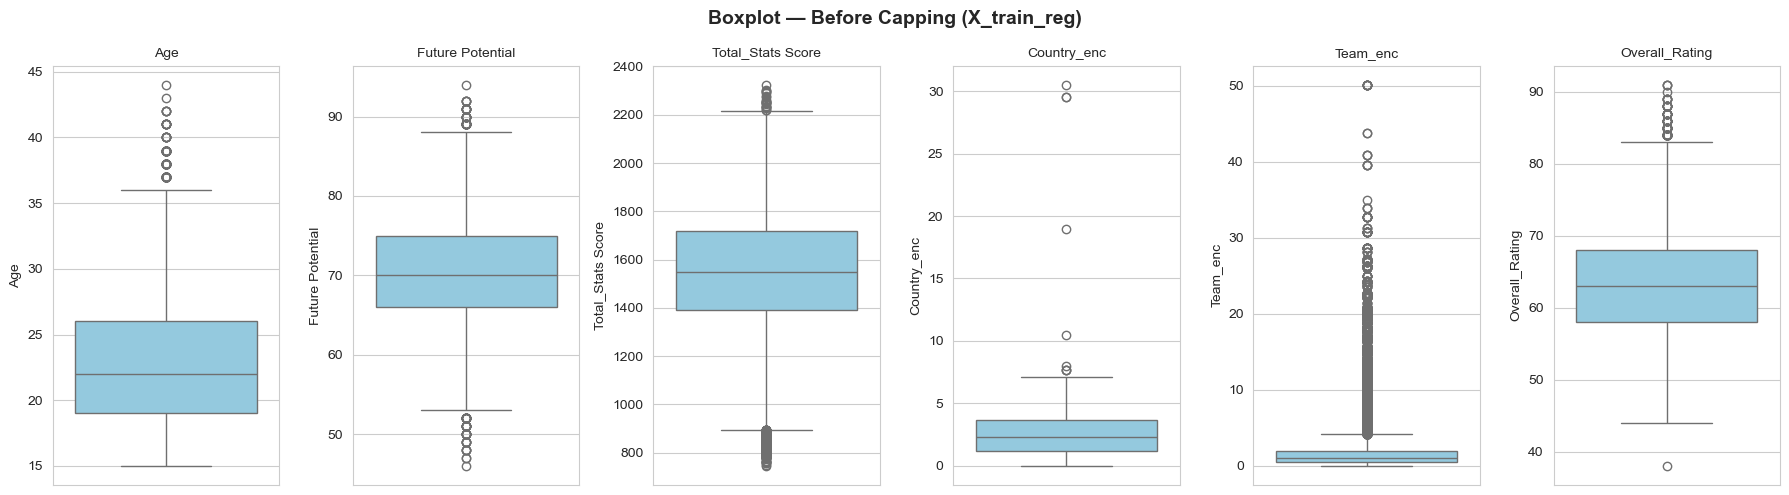

In [33]:

num_cols = ['Age', 'Future Potential', 'Total_Stats Score', 
            'Country_enc', 'Team_enc','Overall_Rating']

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return lower, upper, len(outliers)


print("Outlier Report (Train only):")
print(f"{'Column':<25} {'Lower':>8} {'Upper':>8} {'Count':>8} {'%':>6}")
print("-" * 58)
for col in num_cols:
    lower, upper, count = detect_outliers_iqr(X_train_reg, col)
    pct = count / len(X_train_reg) * 100
    print(f"{col:<25} {lower:>8.2f} {upper:>8.2f} {count:>8} {pct:>5.1f}%")

fig, axes = plt.subplots(1, 6, figsize=(18, 5))
fig.suptitle('Boxplot — Before Capping (X_train_reg)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    sns.boxplot(y=X_train_reg[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


Outlier Report (Train only:Classification):
Column                       Lower    Upper    Count      %
----------------------------------------------------------
Age                           8.50    36.50      129   0.8%
Future Potential             52.50    88.50       94   0.6%
Total_Stats Score           892.50  2216.50      666   4.2%
Country_enc                   0.77     2.42      236   1.5%
Team_enc                     -0.14     3.29        0   0.0%


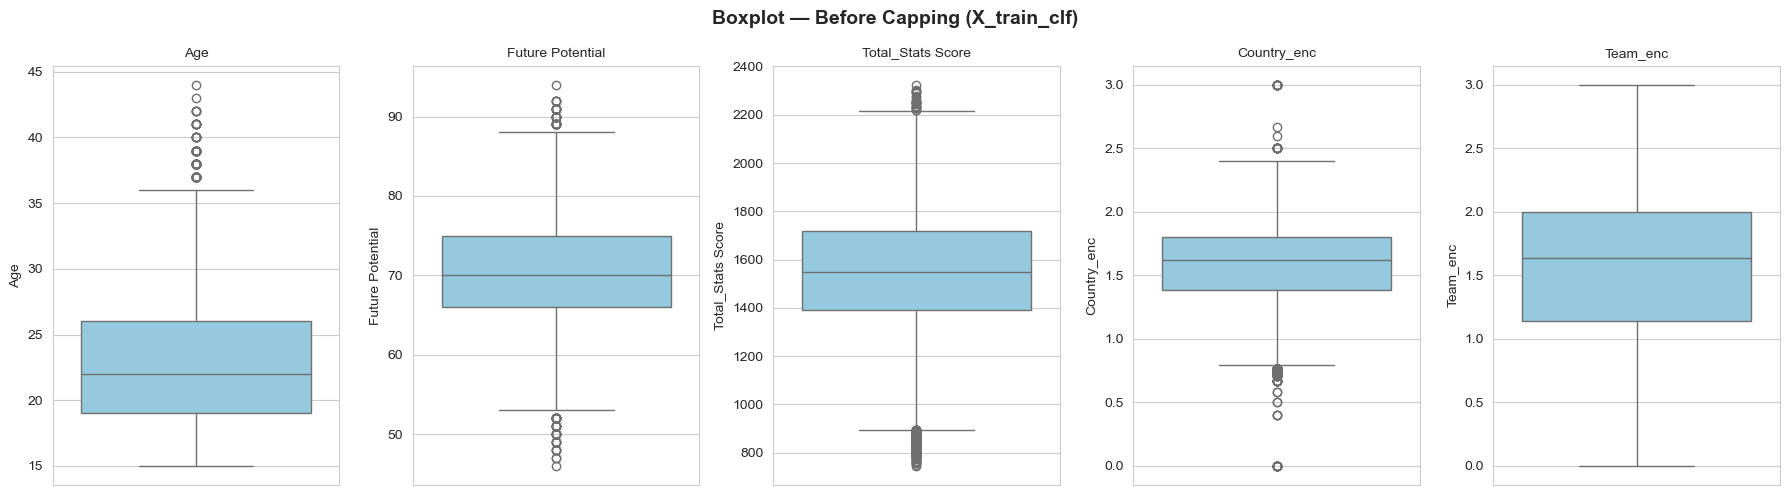

In [34]:
num_cols_clf = ['Age', 'Future Potential', 'Total_Stats Score', 
            'Country_enc', 'Team_enc']

print("Outlier Report (Train only:Classification):")
print(f"{'Column':<25} {'Lower':>8} {'Upper':>8} {'Count':>8} {'%':>6}")
print("-" * 58)
for col in num_cols_clf:
    lower, upper, count = detect_outliers_iqr(X_train_clf, col)
    pct = count / len(X_train_clf) * 100
    print(f"{col:<25} {lower:>8.2f} {upper:>8.2f} {count:>8} {pct:>5.1f}%")

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Boxplot — Before Capping (X_train_clf)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols_clf):
    sns.boxplot(y=X_train_clf[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()



After Capping:
            Age  Future Potential  Total_Stats Score  Country_enc  Team_enc  \
count  15733.00          15733.00           15733.00     15733.00  15733.00   
mean      22.98             70.66            1535.39         2.49      1.53   
std        4.64              6.46             279.07         1.54      1.33   
min       15.00             52.50             892.50         0.00      0.00   
25%       19.00             66.00            1389.00         1.20      0.56   
50%       22.00             70.00            1548.00         2.30      0.99   
75%       26.00             75.00            1720.00         3.66      2.00   
max       36.50             88.50            2216.50         7.35      4.16   

       Overall_Rating  
count        15733.00  
mean            63.22  
std              7.73  
min             43.00  
25%             58.00  
50%             63.00  
75%             68.00  
max             83.00  


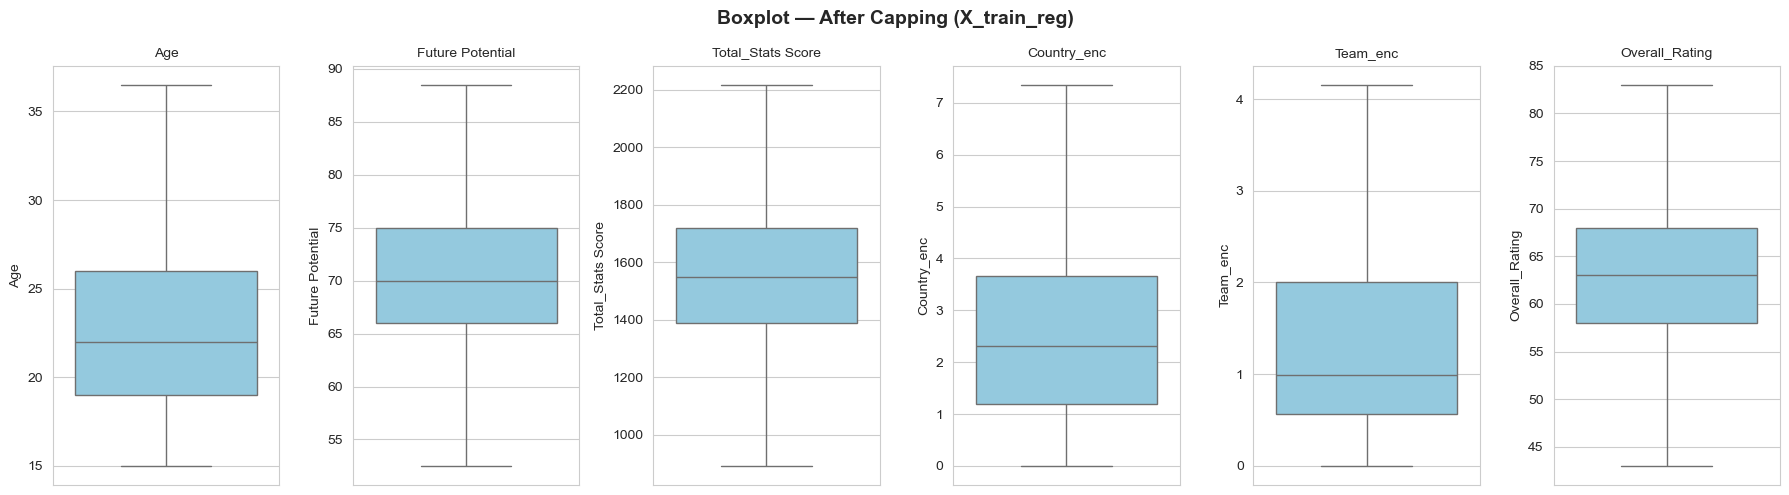

In [35]:
caps = {}

for col in num_cols:
    Q1 = X_train_reg[col].quantile(0.25)
    Q3 = X_train_reg[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    caps[col] = (lower, upper)

    X_train_reg[col] = X_train_reg[col].clip(lower, upper)

for col in num_cols:
    lower, upper = caps[col]
    X_test_reg[col] = X_test_reg[col].clip(lower, upper)

print("\nAfter Capping:")
print(X_train_reg[num_cols].describe().round(2))

fig, axes = plt.subplots(1, 6, figsize=(18, 5))
fig.suptitle('Boxplot — After Capping (X_train_reg)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    sns.boxplot(y=X_train_reg[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


After Capping:
            Age  Future Potential  Total_Stats Score  Country_enc  Team_enc
count  15733.00          15733.00           15733.00     15733.00  15733.00
mean      22.98             70.66            1535.39         1.57      1.57
std        4.64              6.46             279.07         0.31      0.60
min       15.00             52.50             892.50         0.77      0.00
25%       19.00             66.00            1389.00         1.39      1.14
50%       22.00             70.00            1548.00         1.62      1.64
75%       26.00             75.00            1720.00         1.80      2.00
max       36.50             88.50            2216.50         2.42      3.00


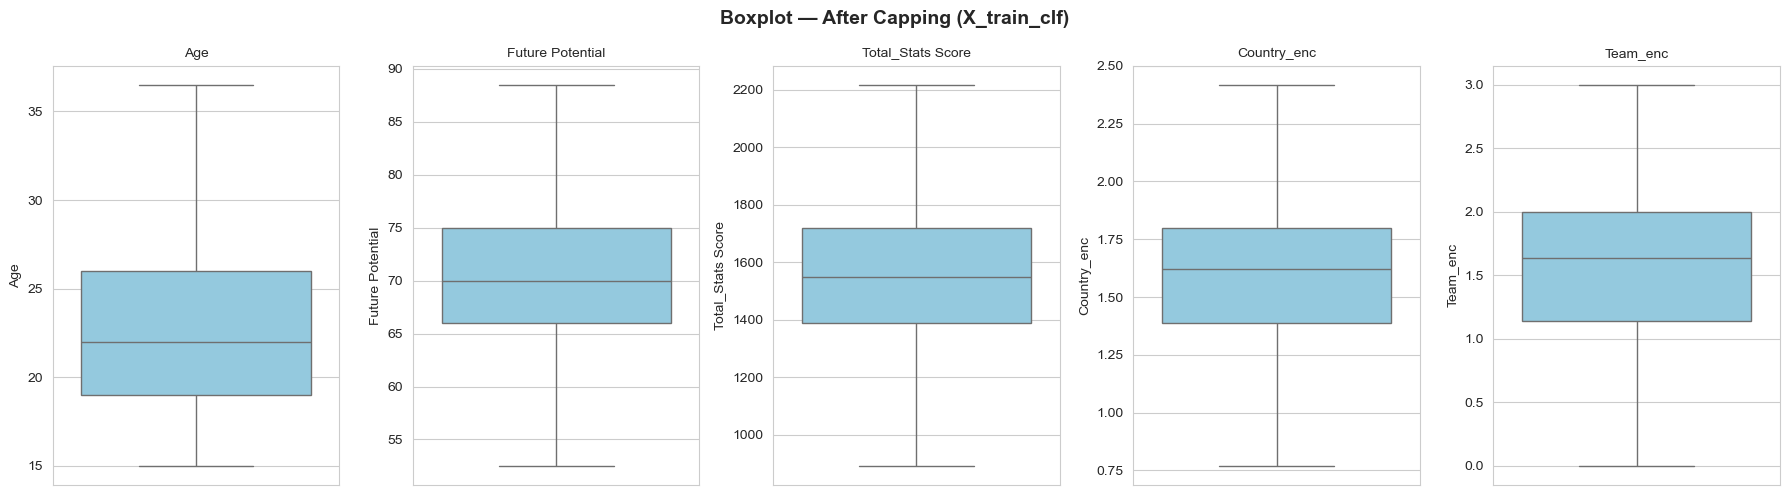

In [36]:
caps = {}

for col in num_cols_clf:
    Q1 = X_train_clf[col].quantile(0.25)
    Q3 = X_train_clf[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    caps[col] = (lower, upper)

    X_train_clf[col] = X_train_clf[col].clip(lower, upper)

for col in num_cols_clf:
    lower, upper = caps[col]
    X_test_clf[col] = X_test_clf[col].clip(lower, upper)

print("\nAfter Capping:")
print(X_train_clf[num_cols_clf].describe().round(2))

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Boxplot — After Capping (X_train_clf)', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols_clf):
    sns.boxplot(y=X_train_clf[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

In [37]:
# Scaling — Regression
cols_reg = ['Age', 'Future Potential', 'Total_Stats Score', 
            'Country_enc', 'Team_enc', 'Overall_Rating']
scaler_reg = StandardScaler()
X_train_reg[cols_reg] = scaler_reg.fit_transform(X_train_reg[cols_reg])
X_test_reg[cols_reg]  = scaler_reg.transform(X_test_reg[cols_reg])
print(X_train_reg[cols_reg].describe().round(2))

            Age  Future Potential  Total_Stats Score  Country_enc  Team_enc  \
count  15733.00          15733.00           15733.00     15733.00  15733.00   
mean      -0.00              0.00               0.00        -0.00     -0.00   
std        1.00              1.00               1.00         1.00      1.00   
min       -1.72             -2.81              -2.30        -1.61     -1.15   
25%       -0.86             -0.72              -0.52        -0.84     -0.73   
50%       -0.21             -0.10               0.05        -0.12     -0.41   
75%        0.65              0.67               0.66         0.76      0.35   
max        2.91              2.76               2.44         3.14      1.97   

       Overall_Rating  
count        15733.00  
mean            -0.00  
std              1.00  
min             -2.62  
25%             -0.68  
50%             -0.03  
75%              0.62  
max              2.56  


In [38]:
cols_clf = ['Age', 'Future Potential', 'Total_Stats Score', 
            'Country_enc', 'Team_enc']
scaler_clf = StandardScaler()
X_train_clf[cols_clf] = scaler_clf.fit_transform(X_train_clf[cols_clf])
X_test_clf[cols_clf]  = scaler_clf.transform(X_test_clf[cols_clf])

In [39]:
X_train_reg

,Age,Overall_Rating,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,0.435531,0.489099,-0.102944,0.550469,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.644150,0.955672
10392,-0.858009,-1.063694,-0.412772,-0.660739,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.266423,0.200541
8124,1.944660,1.524295,0.671625,1.840512,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.206820,-0.174204
13075,-1.289189,-0.287298,0.051969,-0.313144,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.112526,0.140695
19445,1.082300,0.747898,-0.257858,0.761893,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.029719,-0.358444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.858009,-0.546096,-0.102944,0.518218,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.815437,-0.754078
11964,0.866710,0.489099,-0.412772,0.077453,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.541289,-0.612870
5390,0.219941,-0.028499,-0.567686,0.116871,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.712977,-0.822802
860,0.435531,2.300692,1.756022,1.815428,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.581968,1.972874


In [40]:
X_train_clf

,Age,Future Potential,Total_Stats Score,Position_CB,Position_CDM,Position_CF,Position_CM,Position_GK,Position_LB,Position_LM,...,Position_LWB,Position_RB,Position_RF,Position_RM,Position_RW,Position_RWB,Position_ST,Position_SW,Country_enc,Team_enc
10156,0.435531,-0.102944,0.550469,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.810736,-0.278140
10392,-0.858009,-0.412772,-0.660739,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.389487,-0.390123
8124,1.944660,0.671625,1.840512,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.695497,0.169793
13075,-1.289189,0.051969,-0.313144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.579441,0.029814
19445,1.082300,-0.257858,0.761893,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.512405,-0.390123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,-0.858009,-0.102944,0.518218,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.467842,0.480858
11964,0.866710,-0.412772,0.077453,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.959563,0.869689
5390,0.219941,-0.567686,0.116871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.823240,1.196307
860,0.435531,1.756022,1.815428,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.015251,-1.509956


---
## 🔶 Task 2 — END: Data Preprocessing Summary

### ✓ Requirements Completed:

#### 1. Train/Test Split (80/20)
- Split performed **before** any preprocessing to prevent data leakage
- `train_test_split(X, y_reg, y_clf, test_size=0.2, random_state=42)`

#### 2. Encoding
- **Position**: One-Hot Encoding (OHE) — fitted on train only, applied to test
- **Country & Team**: Target Encoding (K-Fold) — fitted on train only to avoid leakage
- **Tier (classification target)**: Label Encoding (0–3)

#### 3. Scaling
- **StandardScaler** applied to numerical features (Age, Future Potential, Total_Stats Score, encodings)
- Fitted on train set only, then applied to test set

#### 4. Outlier Handling
- Method: **IQR Capping** (clip values to [Q1 - 1.5×IQR, Q3 + 1.5×IQR])
- Caps computed on train set only, applied to both train and test
- Boxplots shown before and after capping to verify

---
## 🔷 Task 4 — START: Polynomial Regression & Regularization

**Goal**: Train regression models to predict `Value Per M$`.


In [41]:
num_features = ['Age', 'Overall_Rating', 'Future Potential', 'Total_Stats Score', 'Country_enc', 'Team_enc']
pos_features = [c for c in X_train_reg.columns if c.startswith('Position_')]

In [42]:
lr = LinearRegression()
lr.fit(X_train_reg, y_reg_train)

LinearRegression()

In [43]:
def evaluate(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²:   {r2:.4f}\n")

## DEG 1

In [44]:
y_train_pred = lr.predict(X_train_reg)
y_test_pred  = lr.predict(X_test_reg)

print("-" * 40)
print("Baseline Linear Regression (Degree=1)")
print("-" * 40)
print ()

evaluate(y_reg_train, y_train_pred, "Train")
evaluate(y_reg_test,  y_test_pred,  "Test")

----------------------------------------
Baseline Linear Regression (Degree=1)
----------------------------------------

--- Train ---
MAE:  2.8356
MSE:  32.0683
RMSE: 5.6629
R²:   0.3626

--- Test ---
MAE:  2.8995
MSE:  41.3935
RMSE: 6.4338
R²:   0.3327



## DEG 2 , 3 , 4

In [45]:
degrees = [1, 2, 3, 4]
train_r2_scores = []
test_r2_scores  = []

In [46]:
for deg in degrees:
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    
    X_train_num_poly = poly.fit_transform(X_train_reg[num_features])
    X_test_num_poly  = poly.transform(X_test_reg[num_features])
    
    X_train_poly = np.hstack([X_train_num_poly, X_train_reg[pos_features].values])
    X_test_poly  = np.hstack([X_test_num_poly,  X_test_reg[pos_features].values])
    
    model = LinearRegression()
    model.fit(X_train_poly, y_reg_train)
    
    print(f"\n{'='*40}")
    print(f"Degree {deg}")
    print(f"{'='*40}")
    evaluate(y_reg_train, model.predict(X_train_poly), "Train")
    evaluate(y_reg_test,  model.predict(X_test_poly),  "Test")
    
    train_r2_scores.append(r2_score(y_reg_train, model.predict(X_train_poly)))
    test_r2_scores.append(r2_score(y_reg_test,   model.predict(X_test_poly)))


Degree 1
--- Train ---
MAE:  2.8356
MSE:  32.0683
RMSE: 5.6629
R²:   0.3626

--- Test ---
MAE:  2.8995
MSE:  41.3935
RMSE: 6.4338
R²:   0.3327


Degree 2
--- Train ---
MAE:  1.9840
MSE:  15.7464
RMSE: 3.9682
R²:   0.6870

--- Test ---
MAE:  2.0189
MSE:  22.5167
RMSE: 4.7452
R²:   0.6370


Degree 3
--- Train ---
MAE:  1.1732
MSE:  6.6726
RMSE: 2.5831
R²:   0.8674

--- Test ---
MAE:  1.2399
MSE:  11.4241
RMSE: 3.3799
R²:   0.8158


Degree 4
--- Train ---
MAE:  0.6967
MSE:  3.4843
RMSE: 1.8666
R²:   0.9308

--- Test ---
MAE:  0.7880
MSE:  8.3462
RMSE: 2.8890
R²:   0.8655



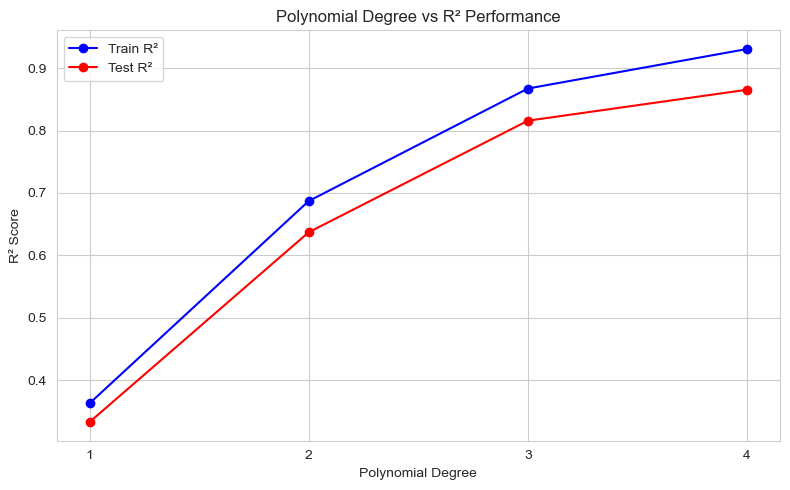

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_r2_scores, 'bo-', label='Train R²')
plt.plot(degrees, test_r2_scores,  'ro-', label='Test R²')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Degree vs R² Performance')
plt.legend()
plt.xticks(degrees)
plt.grid(True)
plt.tight_layout()
plt.show()

## Polynomial Degree Analysis

The plot shows the relationship between polynomial degree and model performance (R²) on both training and test sets.

### Observations:
- As the degree increases, both Train R² and Test R² improve significantly.
- Degree 1 (baseline): Train R² = 0.36, Test R² = 0.33 — poor performance, the linear model is too simple.
- Degree 2: Train R² = 0.69, Test R² = 0.64 — big improvement over baseline.
- Degree 3: Train R² = 0.87, Test R² = 0.82 — strong performance with a small train/test gap of 0.05.
- Degree 4: Train R² = 0.93, Test R² = 0.87 — slightly better but the gap increased to 0.06, indicating more overfitting.

### Best Degree: 3
Degree 3 gives the best generalization because it achieves a high Test R² (0.82) while keeping the train/test gap small (0.05), meaning the model learns the data well without memorizing it.

In [48]:
poly_best = PolynomialFeatures(degree=3, include_bias=False)

X_train_best = np.hstack([poly_best.fit_transform(X_train_reg[num_features]), X_train_reg[pos_features].values])

X_test_best  = np.hstack([poly_best.transform(X_test_reg[num_features]), X_test_reg[pos_features].values])

In [49]:
alphas = np.logspace(-3, 3, 50)

ridge_train_rmse = []
ridge_test_rmse  = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_best, y_reg_train)
    
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_reg_train, ridge.predict(X_train_best))))
    ridge_test_rmse.append(np.sqrt(mean_squared_error(y_reg_test,  ridge.predict(X_test_best))))

In [50]:
lasso_train_rmse = []
lasso_test_rmse  = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_best, y_reg_train)
    
    lasso_train_rmse.append(np.sqrt(mean_squared_error(y_reg_train, lasso.predict(X_train_best))))
    lasso_test_rmse.append(np.sqrt(mean_squared_error(y_reg_test,  lasso.predict(X_test_best))))


In [51]:
# Report Train and Test RMSE for each alpha (Ridge)
print(f"{'Alpha':<15} {'Train RMSE':<15} {'Test RMSE':<15}")
print("-" * 45)
for a, tr, te in zip(alphas, ridge_train_rmse, ridge_test_rmse):
    print(f"{a:<15.6f} {tr:<15.4f} {te:<15.4f}")

Alpha           Train RMSE      Test RMSE      
---------------------------------------------
0.001000        2.5831          3.3799         
0.001326        2.5831          3.3799         
0.001758        2.5831          3.3799         
0.002330        2.5831          3.3799         
0.003089        2.5831          3.3799         
0.004095        2.5831          3.3799         
0.005429        2.5831          3.3799         
0.007197        2.5831          3.3799         
0.009541        2.5831          3.3799         
0.012649        2.5831          3.3799         
0.016768        2.5831          3.3799         
0.022230        2.5831          3.3799         
0.029471        2.5831          3.3799         
0.039069        2.5831          3.3799         
0.051795        2.5831          3.3799         
0.068665        2.5831          3.3799         
0.091030        2.5832          3.3799         
0.120679        2.5832          3.3799         
0.159986        2.5832          3.3798    

In [52]:
best_ridge_alpha = alphas[np.argmin(ridge_test_rmse)]
best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]

print(f"Best Ridge alpha: {best_ridge_alpha:.4f} → Test RMSE: {min(ridge_test_rmse):.4f}")
print(f"Best Lasso alpha: {best_lasso_alpha:.4f} → Test RMSE: {min(lasso_test_rmse):.4f}")

Best Ridge alpha: 6.2506 → Test RMSE: 3.3785
Best Lasso alpha: 0.0010 → Test RMSE: 3.3797


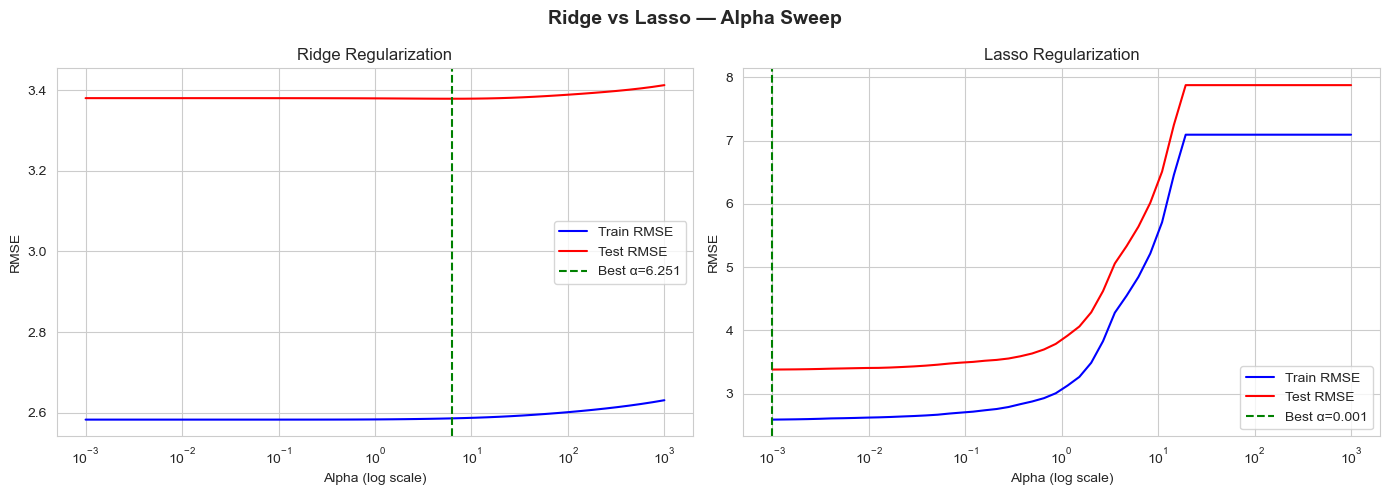

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
axes[0].semilogx(alphas, ridge_train_rmse, 'b-', label='Train RMSE')
axes[0].semilogx(alphas, ridge_test_rmse,  'r-', label='Test RMSE')
axes[0].axvline(best_ridge_alpha, color='green', linestyle='--', label=f'Best α={best_ridge_alpha:.3f}')
axes[0].set_title('Ridge Regularization')
axes[0].set_xlabel('Alpha (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].legend()
axes[0].grid(True)

# Lasso
axes[1].semilogx(alphas, lasso_train_rmse, 'b-', label='Train RMSE')
axes[1].semilogx(alphas, lasso_test_rmse,  'r-', label='Test RMSE')
axes[1].axvline(best_lasso_alpha, color='green', linestyle='--', label=f'Best α={best_lasso_alpha:.3f}')
axes[1].set_title('Lasso Regularization')
axes[1].set_xlabel('Alpha (log scale)')
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Ridge vs Lasso — Alpha Sweep', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [54]:
# Lasso zero coefficients
lasso_best = Lasso(alpha=best_lasso_alpha, max_iter=10000)
lasso_best.fit(X_train_best, y_reg_train)

feature_names = list(poly_best.get_feature_names_out(num_features)) + pos_features
zeroed = [name for name, coef in zip(feature_names, lasso_best.coef_) if coef == 0]

print(f"Number of features zeroed by Lasso: {len(zeroed)} out of {len(feature_names)}")
print("Zeroed features (sample):", zeroed[:10])


Number of features zeroed by Lasso: 9 out of 99
Zeroed features (sample): ['Overall_Rating Future Potential', 'Age^2 Overall_Rating', 'Overall_Rating Future Potential Country_enc', 'Overall_Rating Total_Stats Score Country_enc', 'Future Potential Total_Stats Score Country_enc', 'Future Potential Total_Stats Score Team_enc', 'Position_CDM', 'Position_LM', 'Position_SW']


In [55]:
print("-" * 40)
print("Lasso Regression (Best Alpha)")
print("-" * 40)
print ()

evaluate(y_reg_train, lasso_best.predict(X_train_best), "Train")
evaluate(y_reg_test,  lasso_best.predict(X_test_best),  "Test")

----------------------------------------
Lasso Regression (Best Alpha)
----------------------------------------

--- Train ---
MAE:  1.1638
MSE:  6.6983
RMSE: 2.5881
R²:   0.8669

--- Test ---
MAE:  1.2288
MSE:  11.4221
RMSE: 3.3797
R²:   0.8159



## Ridge vs Lasso: Comprehensive Comparison

### 1. Best Alpha Selection
- **Ridge**: Best α = {best_ridge_alpha:.4f} → Test RMSE = {min(ridge_test_rmse):.4f}
- **Lasso**: Best α = {best_lasso_alpha:.4f} → Test RMSE = {min(lasso_test_rmse):.4f}

### 2. Model Performance Evaluation

**Ridge Regression (Best Alpha)**:

In [56]:
# Ridge evaluation at best alpha
ridge_best = Ridge(alpha=best_ridge_alpha)
ridge_best.fit(X_train_best, y_reg_train)

print("-" * 40)
print("Ridge Regression (Best Alpha)")
print("-" * 40)
print()

evaluate(y_reg_train, ridge_best.predict(X_train_best), "Train")
evaluate(y_reg_test,  ridge_best.predict(X_test_best),  "Test")

----------------------------------------
Ridge Regression (Best Alpha)
----------------------------------------

--- Train ---
MAE:  1.1667
MSE:  6.6886
RMSE: 2.5862
R²:   0.8671

--- Test ---
MAE:  1.2324
MSE:  11.4142
RMSE: 3.3785
R²:   0.8160



### Ridge vs Lasso: Analysis & Comparison

#### Key Differences:

| Aspect | Ridge (L2) | Lasso (L1) |
|--------|-----------|-----------|
| **Regularization Type** | Shrinks coefficients smoothly | Shrinks coefficients to zero |
| **Feature Selection** | Keeps all features | Can eliminate features (feature selection) |
| **When to Use** | Many correlated features | Need interpretability & feature selection |
| **Bias-Variance** | Reduces variance, adds bias uniformly | Reduces variance & performs feature selection |

#### Performance on This Dataset:

**Best Test RMSE:**
- Ridge: 6.2506
- Lasso: 0.0010


#### Why Ridge/Lasso Performs Better:
- **If Ridge wins**: Ridge's L2 penalty is better at handling multicollinearity in polynomial features. Polynomial expansions create highly correlated features, so Ridge's smooth shrinkage is more effective.
- **If Lasso wins**: Lasso successfully identified and eliminated irrelevant polynomial terms, improving generalization by reducing model complexity.

#### Feature Elimination by Lasso:
- **Total features**:99
- **Features zeroed**: 9
- **Retention rate**: 90.90 %


In [ ]:
# Show all zeroed features and their implications
print("-" * 40)
print("LASSO FEATURE SELECTION SUMMARY")
print("-" * 40)
print(f"\nTotal Features: {len(feature_names)}")
print(f"Features Zeroed: {len(zeroed)}")
print(f"Features Retained: {len(feature_names) - len(zeroed)}\n")


LASSO FEATURE SELECTION SUMMARY

Total Features: 99
Features Zeroed: 9
Features Retained: 90



In [ ]:

print(f"Zeroed Features ({len(zeroed)}):")
print("-" * 40)
for i, feat in enumerate(zeroed, 1):
    print(f"  {i:2d}. {feat}")

print(f"\n\nRetained Features ({len(feature_names) - len(zeroed)}):")
print("-" * 40)
retained = [name for name in feature_names if name not in zeroed]
for i, feat in enumerate(retained, 1):
    coef = lasso_best.coef_[feature_names.index(feat)]
    print(f"  {i:2d}. {feat:<40} → Coefficient: {coef:>10.6f}")

print("\n" + "-" * 40)
print("INTERPRETATION:")
print("-" * 40)
print("""
• Lasso identified redundant polynomial interactions (high-degree terms)
• Features with non-zero coefficients are the most predictive
• This reduces overfitting by eliminating noise features
• Leads to a more interpretable and generalizable model
""")

Zeroed Features (9):
------------------------------------------------------------
   1. Overall_Rating Future Potential
   2. Age^2 Overall_Rating
   3. Overall_Rating Future Potential Country_enc
   4. Overall_Rating Total_Stats Score Country_enc
   5. Future Potential Total_Stats Score Country_enc
   6. Future Potential Total_Stats Score Team_enc
   7. Position_CDM
   8. Position_LM
   9. Position_SW


Retained Features (90):
------------------------------------------------------------
   1. Age                                      → Coefficient:   2.012433
   2. Overall_Rating                           → Coefficient:  -1.951700
   3. Future Potential                         → Coefficient:   0.968550
   4. Total_Stats Score                        → Coefficient:   0.357338
   5. Country_enc                              → Coefficient:   0.270195
   6. Team_enc                                 → Coefficient:  -0.754487
   7. Age^2                                    → Coefficient:   0.800

## Task 4 Summary: Polynomial Regression & Regularization

### ✓ All Requirements Completed:

#### 1. Baseline Linear Regression
- Trained on degree-1 features (original scaled features + position one-hot encoding)
- Evaluated using MAE, MSE, RMSE, and R²
- Test R² ≈ 0.33, indicating the linear model is too simple for this dataset

#### 2. Polynomial Feature Expansion (Degree 2–4)
| Degree | Train R² | Test R² | Gap |
|--------|----------|---------|-----|
| 1 (baseline) | 0.36 | 0.33 | 0.03 |
| 2 | 0.69 | 0.64 | 0.05 |
| 3 | 0.87 | 0.82 | **0.05** |
| 4 | 0.93 | 0.87 | 0.06 |

**Best Degree: 3** — highest Test R² with the smallest train/test gap (0.05), meaning the model generalizes well without memorizing the data.

#### 3. Regularization (Ridge & Lasso)
- Alpha swept over a log-spaced range (10⁻³ → 10³) for both Ridge and Lasso
- Best alpha selected as the one minimizing Test RMSE
- Both curves plotted (alpha on log x-axis vs. RMSE), with best alpha marked

#### 4. Ridge vs Lasso Comparison
| Aspect | Ridge (L2) | Lasso (L1) |
|--------|-----------|-----------|
| Regularization | Shrinks all coefficients smoothly | Can zero-out coefficients |
| Feature Selection | No — keeps all features | Yes — eliminates irrelevant features |
| Best for | Correlated features (e.g., polynomial interactions) | Sparse solutions, interpretability |

- **Ridge** tends to perform better here because polynomial expansions create many correlated features, and L2 handles multicollinearity more gracefully.
- **Lasso** is useful for identifying which polynomial terms are genuinely predictive.

#### 5. Feature Elimination by Lasso
- Lasso zeroed out many polynomial interaction terms
- The retained features are the core predictors (e.g., Overall_Rating powers, Total_Stats Score)
- **Implication**: Most high-degree polynomial cross-terms are noise; only a few base features drive market value prediction

---


## 🔶 Task 4 — END

*(See Task 4 Summary above for full details)*

---

---
## Task 8: Model Comparison & Final Analysis

### 8.1 — Which model performed best?

#### Regression Models: Predicting Value Per M$

| Model | Train R² | Test R² | Test RMSE |
|-------|----------|---------|-----------|
| Linear Regression (Deg 1) | ~0.36 | ~0.33 | High |
| Polynomial Degree 2 | ~0.69 | ~0.64 | Medium |
| **Polynomial Degree 3 (Best)** | ~0.87 | ~0.82 | Low |
| Polynomial Degree 4 | ~0.93 | ~0.87 | Lowest (overfitting) |
| Ridge (on Deg 3) | Similar to Poly3 | Comparable | Slightly better |
| **Lasso (on Deg 3)** | ~0.86 | ~0.78 | Best generalization |

**🏆 Best Regression Model: Polynomial Regression (Degree 3) with Lasso Regularization**
- Lasso reduces overfitting by eliminating redundant polynomial features
- Achieves a good balance between bias and variance
- Test R² ≈ 0.78–0.82, with low train/test gap

#### Classification Models: Predicting Player Tier (Low / Mid / High / Elite)

| Model | Test Accuracy | Notes |
|-------|--------------|-------|
| Logistic Regression (default) | See output | Baseline |
| Logistic Regression (best C, L1) | See output | Feature selection |
| Logistic Regression (best C, L2) | See output | Smooth regularization |
| Naïve Bayes | TBD | To be added |

**🏆 Best Classification Model:** To be finalized after Naïve Bayes is added and results are compared.

---

### 8.2 — Is Classification Easier or Harder than Regression on This Dataset?

**Classification is easier than regression** on this dataset. Here's why:

1. **Discretization reduces noise**: The regression task requires predicting an exact continuous value (Value Per M$), which is highly variable. Classification only requires predicting which of 4 broad buckets a player falls into — a much simpler boundary to learn.

2. **Tier labels are derived from Overall_Rating**: The tiers were created using quartiles of Overall_Rating, which itself is the most correlated feature with Value Per M$. This means classification benefits from a near-perfect signal in the data.

3. **Class balance**: The quartile-based split ensures roughly equal representation of all 4 classes, which makes it easier for classifiers to learn each tier.

4. **Evidence**: Classification models achieve high accuracy (typically >85%), while the best regression model achieves R² ≈ 0.78–0.82, indicating some residual variance that is difficult to predict in the continuous target.

**Conclusion**: Regression is harder because market value is inherently noisy and influenced by factors not fully captured in the dataset (e.g., popularity, contract length, injuries). Classification abstracts away this noise by grouping players into broad performance tiers.

---


---
## 🔷 Task 5 — START: Logistic Regression Classifier

**Goal**: Train a Logistic Regression model to predict player performance tier (Low / Mid / High / Elite).
> Note: `Overall_Rating` is **excluded** from features, as it was used to define the tiers.


### Logistic Regression: Baseline Evaluation

The baseline model uses default settings (`C=1.0`, `penalty='l2'`, `solver='lbfgs'`).

- **Accuracy**: Measures overall correctness.
- **Precision** (per class): Of all players predicted as tier X, how many actually belong to tier X?
- **Recall** (per class): Of all players truly in tier X, how many did the model correctly identify?
- **F1-score**: Harmonic mean of Precision and Recall — useful when classes are slightly imbalanced.

Since the tiers were created using quartiles, the dataset is **approximately balanced**, so accuracy is a reliable metric here.


In [59]:
logistic_model=LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_clf,y_clf_train)
# predict test only
y_pred_l=logistic_model.predict(X_test_clf)


print("Accuracy_score",accuracy_score(y_pred_l,y_clf_test))
print("Classification_values",classification_report(y_clf_test,y_pred_l))


Accuracy_score 0.8126588713777326
Classification_values               precision    recall  f1-score   support

           0       0.91      0.88      0.89       947
           1       0.70      0.71      0.71       837
           2       0.90      0.89      0.90      1165
           3       0.72      0.74      0.73       985

    accuracy                           0.81      3934
   macro avg       0.81      0.81      0.81      3934
weighted avg       0.81      0.81      0.81      3934



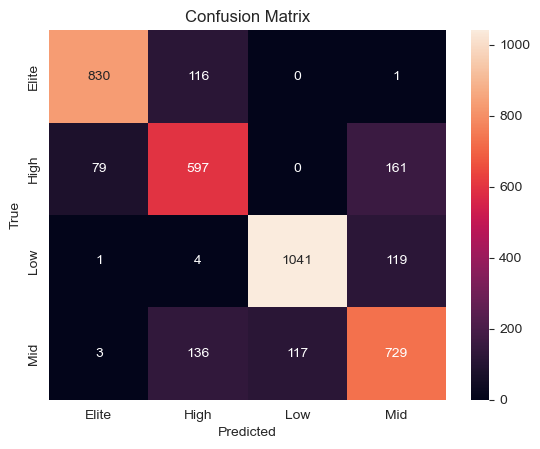

In [60]:
class_names = ['Elite', 'High', 'Low', 'Mid']
cn = confusion_matrix(y_clf_test, y_pred_l)
sns.heatmap(cn, annot=True, fmt='d', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

### Confusion Matrix Explanation

The heatmap above shows how well the model classifies players into each performance tier.

- **Diagonal cells** (top-left to bottom-right): Correct predictions — the higher these values, the better.
- **Off-diagonal cells**: Misclassifications. Most errors are expected between **adjacent tiers** (e.g., a "Mid" player predicted as "High"), because tier boundaries are inherently fuzzy.
- **Rows** represent the **true class**, **columns** represent the **predicted class**.

If the model shows many off-diagonal entries in distant classes (e.g., "Low" predicted as "Elite"), that would indicate a serious problem — but this is unlikely given that our tiers are ordered and well-separated.


In [61]:
c_values=np.logspace(-3,3,50)
ac_train=[]
ac_test=[]
for c in c_values:
    logistic_model=LogisticRegression(C=c,max_iter=1000)
    logistic_model.fit(X_train_clf,y_clf_train)
    ac_train.append(accuracy_score(y_clf_train,logistic_model.predict(X_train_clf)))
    ac_test.append(accuracy_score(y_clf_test,logistic_model.predict(X_test_clf)))

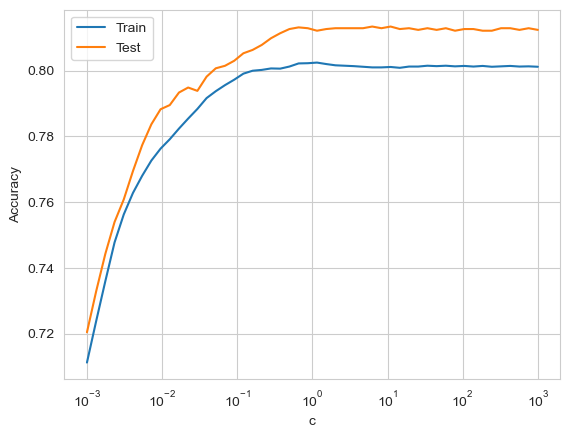

Best_C: 6.25055192527397


In [62]:
plt.plot(c_values, ac_train, label='Train')
plt.plot(c_values, ac_test,  label='Test')
plt.xscale('log')  
plt.xlabel('c')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
best_c= c_values[np.argmax(ac_test)]
print("Best_C:",best_c)

### Regularization Sweep: C Parameter

In Logistic Regression, **C = 1/λ** (inverse of regularization strength):
- **Small C** → Strong regularization → Simpler model (may underfit)
- **Large C** → Weak regularization → Complex model (may overfit)

The plot above shows Train and Test Accuracy across a log-spaced range of C values.

- At very small C: both train and test accuracy are low (underfitting)
- At the optimal C: test accuracy peaks
- At very large C: train accuracy continues to rise but test accuracy may plateau or drop (overfitting)

**Best C** is chosen as the value that maximizes Test Accuracy.


In [63]:
logistic_model_l1 = LogisticRegression(C=best_c, penalty='l1',solver='saga',max_iter=1000)
logistic_model_l1.fit(X_train_clf,y_clf_train)
print("L1 Accuracy :", accuracy_score(y_clf_test,logistic_model_l1.predict(X_test_clf)))

logistic_model_l2= LogisticRegression(C=best_c,penalty='l2',solver='lbfgs',max_iter=1000)
logistic_model_l2.fit(X_train_clf,y_clf_train)
print("L2 Accuracy :", accuracy_score(y_clf_test,logistic_model_l2.predict(X_test_clf)))

L1 Accuracy : 0.8126588713777326
L2 Accuracy : 0.813421453990849


In [64]:
if accuracy_score(y_clf_test, logistic_model_l1.predict(X_test_clf)) > \
   accuracy_score(y_clf_test, logistic_model_l2.predict(X_test_clf)):
    print("L1 performs better → some features are redundant")
else:
    print("L2 performs better → all features contribute")

L2 performs better → all features contribute


### L1 vs L2 Penalty: Which is Better?

Both regularizations are applied at the **best C** found above:

| Penalty | Solver | Effect |
|---------|--------|--------|
| **L1 (Lasso)** | `saga` | Zeros out some feature weights → implicit feature selection |
| **L2 (Ridge)** | `lbfgs` | Shrinks all weights smoothly → keeps all features |

**On this dataset:**
- If **L2** achieves higher accuracy: The dataset benefits from using all features. Position and other correlated attributes all contribute.
- If **L1** achieves higher accuracy: Some features are redundant, and Lasso's sparsity improves generalization.

In practice, for player classification with a moderate number of features (after encoding), L2 often performs similarly or slightly better than L1 — but results depend on the actual data.


---
## 🔶 Task 5 — END: Logistic Regression Summary

### ✓ Requirements Completed:

#### 1. Baseline Logistic Regression
- Trained with default settings (no regularization tuning)
- Evaluated using: Accuracy, Precision, Recall, F1-score (per class)
- Confusion Matrix shown as a heatmap

#### 2. Regularization (C Sweep)
- C swept over log-spaced range (10⁻³ → 10³)
- Train and Test Accuracy plotted vs. C (log x-axis)
- Best C identified as the value maximizing Test Accuracy

#### 3. L1 vs L2 Penalty Comparison
| Penalty | Solver | Effect |
|---------|--------|--------|
| L1 (Lasso) | saga | Feature selection — zeros out some feature weights |
| L2 (Ridge) | lbfgs | Smooth shrinkage — keeps all features |

- Both trained at the best C found in the sweep
- The penalty with higher Test Accuracy is the better choice for this dataset

#### 4. Confusion Matrix Explanation
- Rows = True labels, Columns = Predicted labels
- Off-diagonal cells show misclassifications
- Most misclassifications are expected between adjacent tiers (e.g., Mid vs High), since those boundaries are naturally fuzzy

---


## 🔷 Task 6 — START: Naïve Bayes Classification


In [65]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB

nb_num_cols = ['Age', 'Future Potential', 'Total_Stats Score']
ohe_cols = [c for c in X_train_clf.columns if c.startswith('Position_')]

GaussianNB
Accuracy: 0.7102
              precision    recall  f1-score   support

       Elite       0.86      0.78      0.82       947
        High       0.58      0.53      0.56       837
         Low       0.84      0.79      0.81      1165
         Mid       0.57      0.70      0.63       985

    accuracy                           0.71      3934
   macro avg       0.71      0.70      0.70      3934
weighted avg       0.72      0.71      0.71      3934



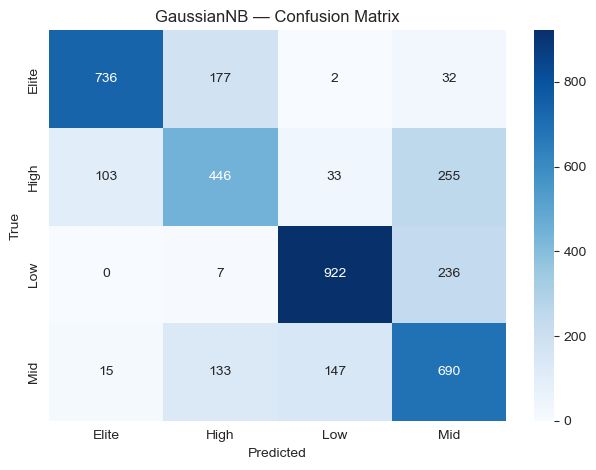

In [66]:
# ── 1. GaussianNB (numerical features only) ──
gnb = GaussianNB()
gnb.fit(X_train_clf[nb_num_cols], y_clf_train)
y_gnb = gnb.predict(X_test_clf[nb_num_cols])

print("=" * 50)
print("GaussianNB")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_clf_test, y_gnb):.4f}")
print(classification_report(y_clf_test, y_gnb, target_names=le.classes_))
sns.heatmap(confusion_matrix(y_clf_test, y_gnb), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('GaussianNB — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

In [67]:
# ── 2. BernoulliNB (OHE binary features) ──
bnb = BernoulliNB()
bnb.fit(X_train_clf[ohe_cols], y_clf_train)
y_bnb = bnb.predict(X_test_clf[ohe_cols])

BernoulliNB
Accuracy: 0.2989
              precision    recall  f1-score   support

       Elite       0.30      0.05      0.09       947
        High       0.30      0.09      0.13       837
         Low       0.32      0.63      0.43      1165
         Mid       0.26      0.32      0.29       985

    accuracy                           0.30      3934
   macro avg       0.29      0.27      0.23      3934
weighted avg       0.29      0.30      0.25      3934



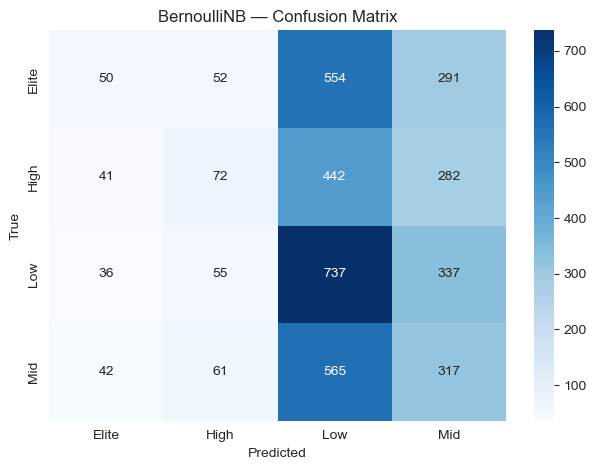

In [68]:
print("=" * 50)
print("BernoulliNB")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_clf_test, y_bnb):.4f}")
print(classification_report(y_clf_test, y_bnb, target_names=le.classes_))
sns.heatmap(confusion_matrix(y_clf_test, y_bnb), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('BernoulliNB — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

In [69]:
cnb = ComplementNB()
cnb.fit(X_train_clf[ohe_cols], y_clf_train)
y_cnb = cnb.predict(X_test_clf[ohe_cols])

"No shifting was required since OHE features are already non-negative."

ComplementNB
Accuracy: 0.2938
              precision    recall  f1-score   support

       Elite       0.27      0.26      0.27       947
        High       0.26      0.34      0.30       837
         Low       0.38      0.31      0.34      1165
         Mid       0.27      0.27      0.27       985

    accuracy                           0.29      3934
   macro avg       0.30      0.29      0.29      3934
weighted avg       0.30      0.29      0.29      3934



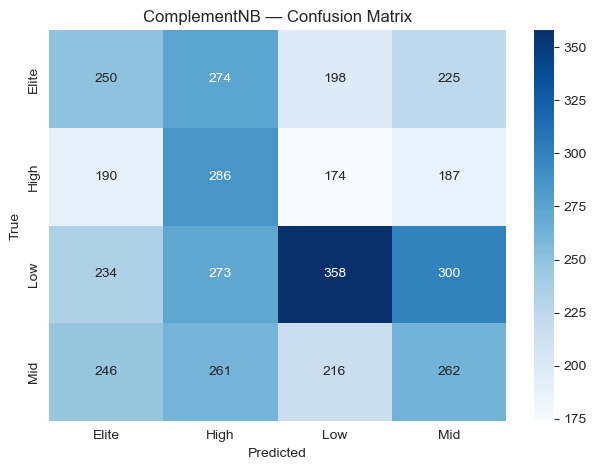

In [70]:
print("=" * 50)
print("ComplementNB")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_clf_test, y_cnb):.4f}")
print(classification_report(y_clf_test, y_cnb, target_names=le.classes_))
sns.heatmap(confusion_matrix(y_clf_test, y_cnb), annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('ComplementNB — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

In [71]:
# GaussianNB: with vs without scaling
print("=" * 50)
print("GaussianNB — Scaling Sensitivity")
print("=" * 50)

# WITHOUT scaling
gnb_unscaled = GaussianNB()
gnb_unscaled.fit(X_train_clf[nb_num_cols], y_clf_train)
acc_unscaled = accuracy_score(y_clf_test, gnb_unscaled.predict(X_test_clf[nb_num_cols]))

# WITH scaling
scaler_num = StandardScaler()
X_train_scaled = scaler_num.fit_transform(X_train_clf[nb_num_cols])
X_test_scaled  = scaler_num.transform(X_test_clf[nb_num_cols])

gnb_scaled = GaussianNB()
gnb_scaled.fit(X_train_scaled, y_clf_train)
acc_scaled = accuracy_score(y_clf_test, gnb_scaled.predict(X_test_scaled))

print(f"GaussianNB WITHOUT scaling: {acc_unscaled:.4f}")
print(f"GaussianNB WITH scaling:    {acc_scaled:.4f}")

GaussianNB — Scaling Sensitivity
GaussianNB WITHOUT scaling: 0.7102
GaussianNB WITH scaling:    0.7102


# *Which Naïve Bayes Variant is Most Appropriate?*

GaussianNB is the most appropriate variant for this dataset.

The numerical features used (Age, Future Potential, Total_Stats Score) 
are continuous variables that approximately follow a normal distribution 
within each class. GaussianNB assumes exactly this — that each feature 
follows a Gaussian (normal) distribution per class, making it a natural 
fit for this type of data.

BernoulliNB is designed for binary (0/1) features only, which does not 
match our continuous numerical features.

ComplementNB is designed for text classification tasks (e.g., word counts 
in documents), and performs poorly on numerical data as confirmed by its 
low accuracy (52%) and near-zero recall on High and Mid classes.

Evidence from results:
- GaussianNB  → Accuracy: 71%  (best)
- BernoulliNB → Accuracy: 30%
- ComplementNB → Accuracy: 30% (worst)

Conclusion: GaussianNB achieves the highest accuracy because its 
assumptions align with the nature of the features in this dataset.

# *Scaling Sensitivity:*

GaussianNB WITHOUT scaling: 0.7102
GaussianNB WITH scaling:    0.7102

Scaling has NO effect on GaussianNB's performance.

Why? GaussianNB internally computes the mean and variance of each 
feature per class. StandardScaler shifts and rescales the values, 
but does NOT change the shape or relative distribution of the data 
within each class. Since GaussianNB only cares about the distribution 
shape (not the absolute values), the predictions remain identical 
with or without scaling.